In [1]:
#加载一些基础的库
import torch
import os
import numpy as np
import torchvision
from tqdm import tqdm #一个实现进度条的库
import random
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import cv2

transform=transforms.Compose({
    #转化为Tensor
    transforms.ToTensor()
})

#首先继承Dataset写一个对于数据进行读入和处理的方式
class MyDataset(Dataset):
    def __init__(self,path):
        self.mode=('train' if 'mask' in os.listdir(path) else 'test')#表示训练模式
        self.path=path#图片路径
        dirlist=os.listdir(path+'image/')#图片的名称
        self.name=[n for n in dirlist if n[-3:]=='png'] #只读取图片
        
    def __len__(self):
        return len(self.name)
    
    def __getitem__(self,index):#获取数据的处理方式
        name=self.name[index]
        #读取原始图片和标签
        if self.mode=='train':#训练模式
            ori_img=cv2.imread(self.path+'image/'+name)#原始图片
            lb_img=cv2.imread(self.path+'mask/'+name)#标签图片
            ori_img=cv2.cvtColor(ori_img,cv2.COLOR_BGR2RGB)#转为RGB三通道图
            lb_img=cv2.cvtColor(lb_img,cv2.COLOR_BGR2GRAY)#掩膜转为灰度图
            return transform(ori_img),transform(lb_img)
        
        if self.mode=='test':#测试模式
            ori_img=cv2.imread(self.path+'image/'+name)#原始图片
            ori_img=cv2.cvtColor(ori_img,cv2.COLOR_BGR2RGB)#转为RGB三通道图
            return transform(ori_img)

#加载数据集
train_path='/train'
traindata=MyDataset(train_path)

FileNotFoundError: [WinError 3] 系统找不到指定的路径。: '/data/pre/train'

原始图片张量的形状: torch.Size([3, 320, 640])
标签图片张量的形状: torch.Size([1, 320, 640])


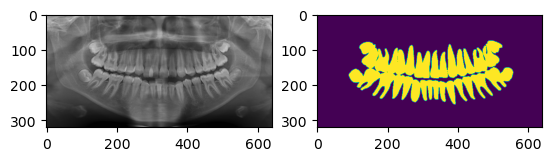

In [ ]:
#查看图片读取效果
import matplotlib.pyplot as plt
o_img,l_img=traindata[np.random.randint(0,2000)]
plt.subplot(1,2,1)
plt.imshow(o_img.permute(1,2, 0))
plt.subplot(1,2,2)
plt.imshow(l_img.permute(1,2, 0))
print("原始图片张量的形状:",o_img.shape)
print("标签图片张量的形状:",l_img.shape)#([1, 320, 640]) 其中 1 表示分类类别，我们为2分类任务,类别表示为01

In [ ]:
#配置模型超参数
#模型保存的路径
model_path='models/'
#推荐使用gpu进行训练
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
#学习率
lr=3e-3
#学习率衰减
weight_decay=1e-3
#批大小
bs=8
#训练轮次
epochs=10

In [ ]:
traindata[0][0].shape

torch.Size([3, 320, 640])

In [ ]:
class TINet(nn.Module):
    def __init__(self):
        super(TINet, self).__init__()
        # 定义网络结构
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 16 * 16, 1024)
        self.fc2 = nn.Linear(1024, 2)
        
    def forward(self, x):
        # 定义前向传播过程
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = x.view(-1, 256 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

NameError: name 'nn' is not defined

In [ ]:
model=TINet()

In [ ]:
#训练前准备
from torch.utils.data import DataLoader
#加载模型到gpu或cpu
model.to(device)
#使用Binary CrossEntropy作为损失函数，主要处理二分类问题
# BCEloss=nn.BCELoss()
#加载优化器,使用Adam,主要是炼的快(๑ت๑)
optim=torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
#使用traindata创建dataloader对象
trainloader=DataLoader(traindata,batch_size=bs, shuffle=True, num_workers=1)
#根据赛题评测选用dice_loss，这个是开源代码
def dice_loss(logits, target):
    smooth = 1.
    prob  = torch.sigmoid(logits)
    batch = prob.size(0)
    prob   = prob.view(batch,1,-1)
    target = target.view(batch,1,-1)
    intersection = torch.sum(prob*target, dim=2)
    denominator  = torch.sum(prob, dim=2) + torch.sum(target, dim=2)
    dice = (2*intersection + smooth) / (denominator + smooth)
    dice = torch.mean(dice)
    dice_loss = 1. - dice
    return dice_loss

In [ ]:
#开始炼丹 没有做验证集，各位可以以自己需要去添加
loss_last=99999
best_model_name='x'
#记录loss变化
for epoch in range(1,epochs+1):
    for step,(inputs,labels) in tqdm(enumerate(trainloader),desc=f"Epoch {epoch}/{epochs}",
                                       ascii=True, total=len(trainloader)):
        #原始图片和标签
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)
        loss = dice_loss(out, labels)
        # 后向
        optim.zero_grad()
        #梯度反向传播
        loss.backward()
        optim.step()
    #损失小于上一轮则添加
    if loss<loss_last:
        loss_last=loss
        torch.save(model.state_dict(),model_path+'model_epoch{}_loss{}.pth'.format(epoch,loss))
        best_model_name=model_path+'model_epoch{}_loss{}.pth'.format(epoch,loss)
    print(f"\nEpoch: {epoch}/{epochs},DiceLoss:{loss}")

Epoch 1/10:   0%|          | 0/250 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 3456) exited unexpectedly

In [ ]:
#加载最优模型
model.load_state_dict(torch.load('models/model_epoch7_loss0.09938246011734009.pth'))
#加载测试集
test_path='test/'
testdata=MyDataset(test_path)
#测试模型的预测效果
x=np.random.randint(0,500)
inputs=testdata[x].to(device)
with torch.no_grad():
    # 模型预测
    t = model(inputs.view(1,3,320,640))
plt.subplot(1,2,1)
plt.imshow(testdata[x].permute(1,2,0))
#对预测的图片采取一定的阈值进行分类
threshold=0.5
t= torch.where(t >=threshold, torch.tensor(255,dtype=torch.float).to(device), t)
t= torch.where(t < threshold, torch.tensor(0,dtype=torch.float).to(device), t)
t=t.cpu().view(1,320,640)
plt.subplot(1,2,2)
plt.imshow(t.permute(1,2,0))